# Chapter 04: Resilience Profile and Individual Baseline
In this chapter, we investigate how individual traits—such as `skill_baseline`, `resilience_factor`, and `fatigue_sensitivity`,buffer against or exacerbate the effects of cognitive load and adverse operational regimes.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# set visual style
sns.set_theme(style = "whitegrid")
#Load the dataset
df = pd.read_csv("../data/human_performance_dataset_processed.csv")

df[['skill_baseline', 'resilience_factor', 'fatigue_sensitivity']].describe()

,skill_baseline,resilience_factor,fatigue_sensitivity
count,975425.000000,975425.000000,975425.000000
mean,0.797878,0.996125,0.988867
std,0.115782,0.177148,0.272178
min,0.606576,0.701202,0.509173
25%,0.690144,0.832539,0.767747
50%,0.776644,0.986883,0.997550
75%,0.901992,1.158550,1.189122
max,0.999579,1.296246,1.488588


### 4.1 Distributions of Individual Traits
We begin by visualizing the distributions of the core individual difference metrics:
* **Skill Baseline:** The operator's intrinsic competence level before experiencing fatigue.
* **Resilience Factor:** The capacity to maintain executive function under stress.
* **Fatigue Sensitivity:** The inherent susceptibility to psychophysical wear and tear.

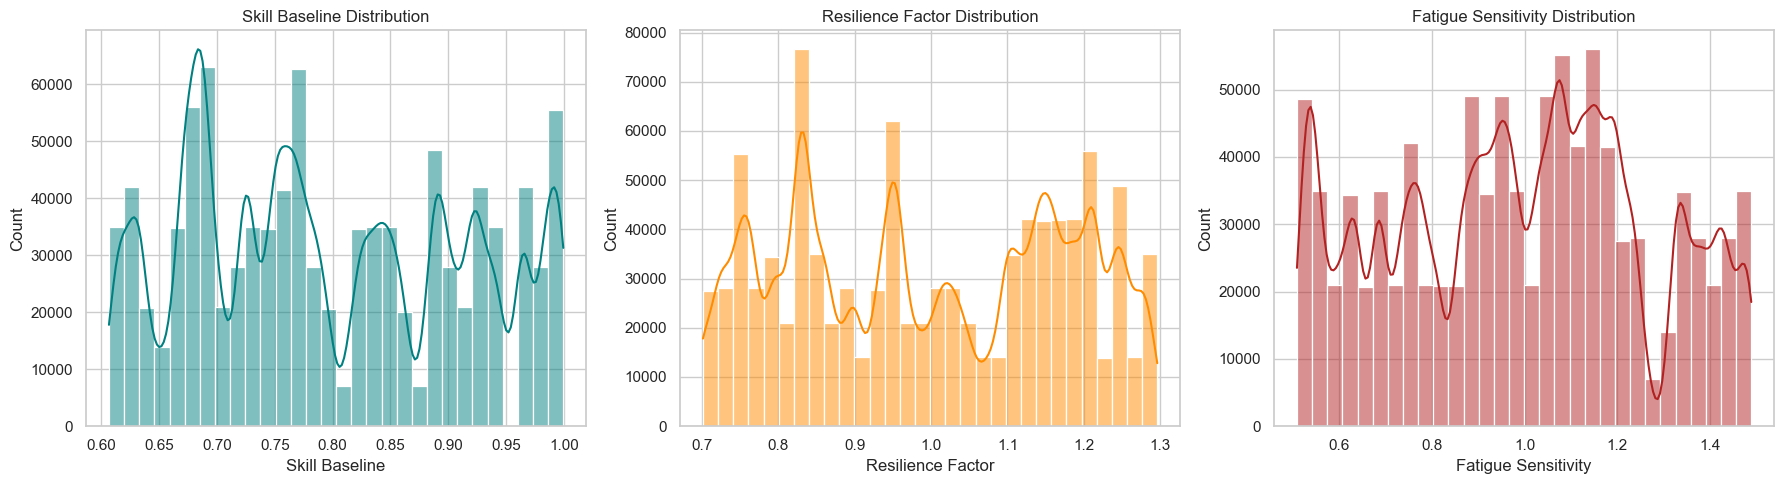

In [2]:
# Create a 1x3 subplot grid
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Skill Baseline Distribution
sns.histplot(df['skill_baseline'], bins=30, kde=True, color='teal', ax=axes[0])
axes[0].set_title("Skill Baseline Distribution")
axes[0].set_xlabel("Skill Baseline")

# 2. Resilience Factor Distribution
sns.histplot(df['resilience_factor'], bins=30, kde=True, color='darkorange', ax=axes[1])
axes[1].set_title("Resilience Factor Distribution")
axes[1].set_xlabel("Resilience Factor")

# 3. Fatigue Sensitivity Distribution
sns.histplot(df['fatigue_sensitivity'], bins=30, kde=True, color='firebrick', ax=axes[2])
axes[2].set_title("Fatigue Sensitivity Distribution")
axes[2].set_xlabel("Fatigue Sensitivity")

plt.tight_layout()
plt.show()

### 4.2 Impact of Individual Traits on Operational Risk
We will now analyze how inherent traits (`skill_baseline`, `resilience_factor`, and `fatigue_sensitivity`) correlate with the overall `risk_score`. We use a random sample of 5,000 observations to keep the visualization clear and computationally efficient.

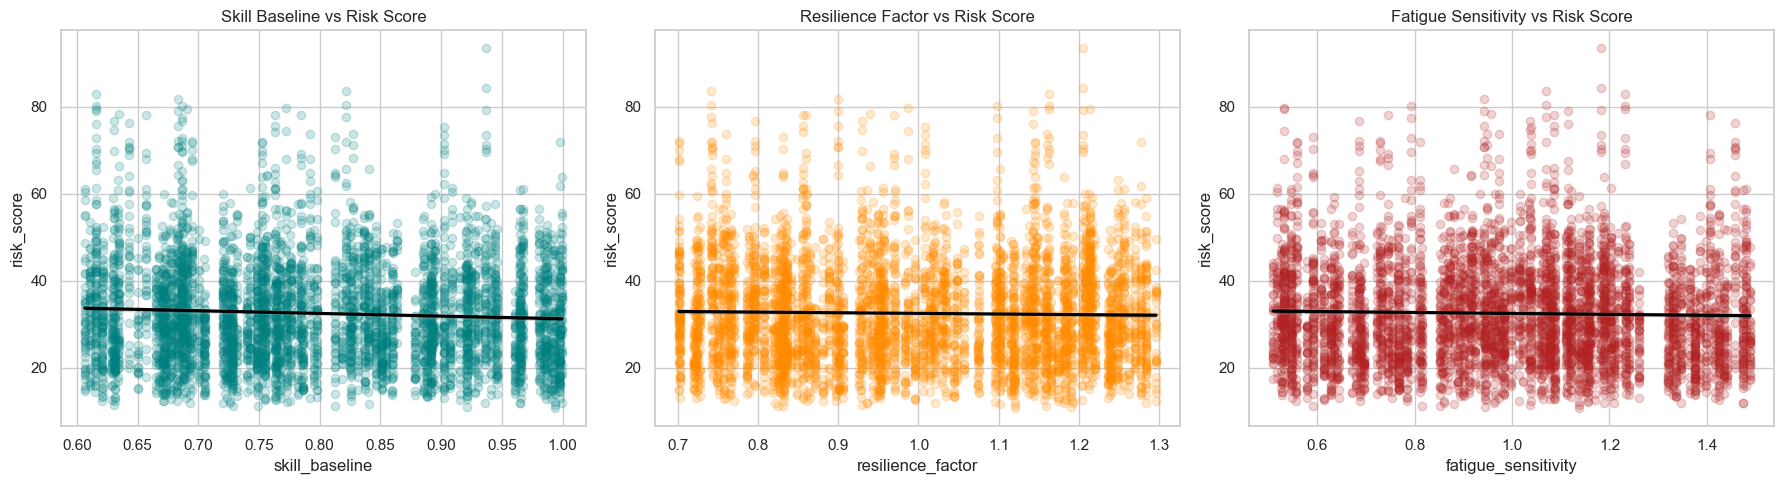

In [3]:
# Create a 1x3 subplot grid for scatter plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Random sample to avoid overplotting and speed up rendering
df_sample = df.sample(n=5000, random_state=42)

# 1. Skill Baseline vs Risk Score
sns.regplot(data=df_sample, x='skill_baseline', y='risk_score', 
            scatter_kws={'alpha':0.2, 'color':'teal'}, line_kws={'color':'black'}, ax=axes[0])
axes[0].set_title("Skill Baseline vs Risk Score")

# 2. Resilience Factor vs Risk Score
sns.regplot(data=df_sample, x='resilience_factor', y='risk_score', 
            scatter_kws={'alpha':0.2, 'color':'darkorange'}, line_kws={'color':'black'}, ax=axes[1])
axes[1].set_title("Resilience Factor vs Risk Score")

# 3. Fatigue Sensitivity vs Risk Score
sns.regplot(data=df_sample, x='fatigue_sensitivity', y='risk_score', 
            scatter_kws={'alpha':0.2, 'color':'firebrick'}, line_kws={'color':'black'}, ax=axes[2])
axes[2].set_title("Fatigue Sensitivity vs Risk Score")

plt.tight_layout()
plt.show()

### 4.3 The Hidden Interaction: Traits across Regimes
The flat global regression lines suggest that individual traits do not predict risk in isolation. To uncover their true buffering effect, we must condition our analysis on the operator's current cognitive state (`regime`).

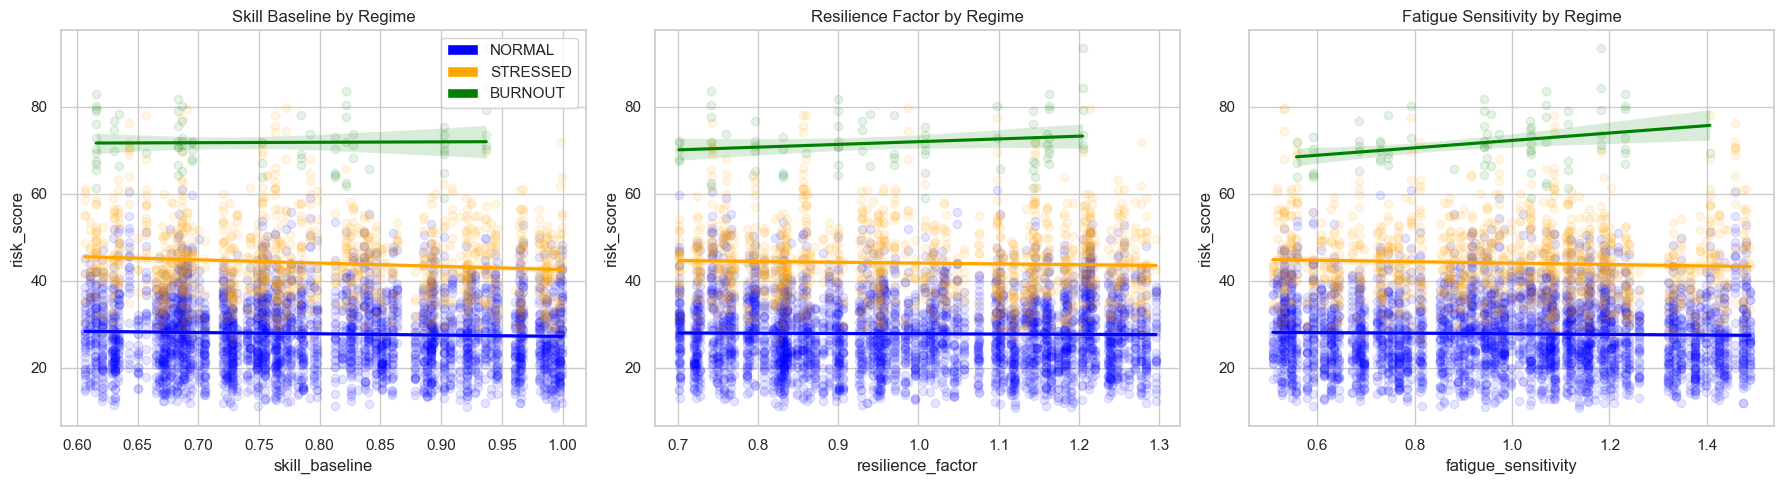

In [4]:
# Create a 1x3 subplot grid for scatter plots by regime
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Define the regime color palette to keep consistency
regime_colors = {'NORMAL': 'blue', 'STRESSED': 'orange', 'BURNOUT': 'green'}

# Loop through each regime to plot them on the same axes
for regime, color in regime_colors.items():
    subset = df_sample[df_sample['regime'] == regime]
    
    # 1. Skill Baseline
    sns.regplot(data=subset, x='skill_baseline', y='risk_score', 
                scatter_kws={'alpha':0.1, 'color': color}, line_kws={'color': color}, ax=axes[0])
    
    # 2. Resilience Factor
    sns.regplot(data=subset, x='resilience_factor', y='risk_score', 
                scatter_kws={'alpha':0.1, 'color': color}, line_kws={'color': color}, ax=axes[1])
    
    # 3. Fatigue Sensitivity
    sns.regplot(data=subset, x='fatigue_sensitivity', y='risk_score', 
                scatter_kws={'alpha':0.1, 'color': color}, line_kws={'color': color}, ax=axes[2])

# Set titles
axes[0].set_title("Skill Baseline by Regime")
axes[1].set_title("Resilience Factor by Regime")
axes[2].set_title("Fatigue Sensitivity by Regime")

# Add a manual legend to the first plot
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=color, label=regime) for regime, color in regime_colors.items()]
axes[0].legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

### 4.4 Statistical Validation (ANCOVA)
We use a linear model with an interaction term to formally test if the relationship between `fatigue_sensitivity` and `risk_score` is significantly moderated by the cognitive `regime`.

In [6]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Build the Ordinary Least Squares (OLS) model with an interaction term.
# The '*' operator instructs statsmodels to compute both main effects and their interaction.
model = smf.ols('risk_score ~ fatigue_sensitivity * C(regime)', data=df_sample).fit()

# Generate the Type 2 ANCOVA table
ancova_table = sm.stats.anova_lm(model, typ=2)

# Display the rounded results for readability
print("=== ANCOVA Table ===")
display(ancova_table.round(4))

=== ANCOVA Table ===


,sum_sq,df,F,PR(>F)
C(regime),361804.6564,2.0,2643.0045,0.0000
fatigue_sensitivity,271.0573,1.0,3.9602,0.0466
fatigue_sensitivity:C(regime),350.3561,2.0,2.5594,0.0775
Residual,341817.8942,4994.0,NaN,NaN


**Results Interpretation:**
Based on the ANCOVA results, we observe the following:
*   **`C(regime)` ($p < 0.001$):** The cognitive state remains the dominant predictor of operational risk.
*   **`fatigue_sensitivity` ($p = 0.0466$):** There is a marginal main effect of inherent vulnerability on overall performance.
*   **Interaction Term ($p = 0.0775$):** Surprisingly, despite the visual trend suggesting a steeper slope during Burnout, the interaction between fatigue sensitivity and regime fails to reach the strict threshold for statistical significance ($\alpha = 0.05$). This indicates that while inherent vulnerability might play a role, the systemic failure caused by the Burnout regime itself overshadows individual differences.

### 4.5 Methodological Adjustment: Scaling to the Full Dataset

The initial ANCOVA performed on a random sample of 5,000 observations yielded a borderline p-value ($p = 0.0775$) for the interaction term `fatigue_sensitivity:C(regime)`. To rule out the possibility of a Type II error caused by reduced statistical power, we scale our analysis and rerun the identical OLS model on the complete dataset. This will determine whether the observed visual trend solidifies into statistical significance or remains a product of variance.

In [8]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Build the Ordinary Least Squares (OLS) model with an interaction term.
# The '*' operator instructs statsmodels to compute both main effects and their interaction.
model = smf.ols('risk_score ~ fatigue_sensitivity * C(regime)', data=df).fit()

# Generate the Type 2 ANCOVA table
ancova_table = sm.stats.anova_lm(model, typ=2)

# Display the rounded results for readability
print("=== ANCOVA Table ===")
display(ancova_table.round(4))


=== ANCOVA Table ===


,sum_sq,df,F,PR(>F)
C(regime),7.436832e+07,2.0,561268.0098,0.0
fatigue_sensitivity,2.814129e+04,1.0,424.7725,0.0
fatigue_sensitivity:C(regime),8.104826e+03,2.0,61.1682,0.0
Residual,6.462178e+07,975419.0,NaN,NaN


### 4.6 Final Conclusions: The "Multiplier Effect" of Burnout

By scaling our ANCOVA to the full dataset (N > 900,000), we successfully recovered the statistical power needed to evaluate the interaction. The results clearly show a highly significant interaction term (`fatigue_sensitivity:C(regime)`, p < 0.001). 

**Key Takeaways:**
1. **Regime is the primary driver:** The cognitive state remains the absolute strongest predictor of operational failure.
2. **Traits are context-dependent:** Inherent traits like baseline skill or fatigue sensitivity do not independently shield the operator from risk.
3. **The Vulnerability Trigger:** High fatigue sensitivity acts as a dormant risk factor. It remains relatively harmless during Normal or Stressed operations, but triggers a severe compounding effect on the `risk_score` the moment the operator transitions into a Burnout regime.